# Heart Rate Interval Segmentation

Detects workout interval boundaries using only HR data.

**Just run all cells from top to bottom!**

## 1. Install Dependencies (Run Once)

In [2]:
#!pip install numpy pandas scikit-learn xgboost scipy matplotlib seaborn --break-system-packages

## 2. Imports

In [3]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ Imports complete")

✓ Imports complete


## 3. Configuration

In [4]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 42
    
    # Feature engineering
    short_window: int = 30
    medium_window: int = 60
    long_window: int = 120
    
    # Model
    model_type: str = "xgboost"  # or "random_forest"
    xgb_max_depth: int = 6
    xgb_n_estimators: int = 200
    xgb_learning_rate: float = 0.1
    xgb_scale_pos_weight: float = 50.0
    
    # Post-processing
    peak_distance: int = 30 #minimum time between detected interval boundaries
    peak_prominence: float = 0.1
    smooth_sigma: float = 5.0 #smoothing for transitions

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 4. Your Data Configuration

In [5]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all",
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2']
  Test sessions: 11


## 5. Feature Engineering Functions

In [6]:
def create_hr_features(df: pd.DataFrame, config: Config) -> pd.DataFrame:
    """Create rich feature set from heart rate time series."""
    features = pd.DataFrame(index=df.index)
    
    hr = df['heart_rate'].values
    
    # Smoothed HR at different scales
    features['hr_raw'] = hr
    features['hr_smooth_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).mean()
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()
    
    # Derivatives - rate of change
    features['hr_diff_1s'] = df['heart_rate'].diff(1)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)
    features['hr_accel'] = features['hr_diff_1s'].diff(1)
    
    # Rolling statistics - short window
    features['hr_std_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).std()
    features['hr_min_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).min()
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()
    features['hr_range_short'] = features['hr_max_short'] - features['hr_min_short']
    
    # Rolling statistics - medium window
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    
    # Relative features
    features['hr_vs_short_baseline'] = hr - features['hr_smooth_short']
    features['hr_vs_medium_baseline'] = hr - features['hr_smooth_medium']
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']
    
    # Trend indicators
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)
    features['hr_decreasing'] = (features['hr_diff_10s'] < 0).astype(int)
    features['hr_stable'] = (features['hr_diff_10s'].abs() < 1).astype(int)
    
    # Lagged features
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_60s'] = df['heart_rate'].shift(60)
    features['hr_lag_90s'] = df['heart_rate'].shift(90)
    
    # Forward looking
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)
    
    # Change
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - features['hr_lag_60s']
    
    # Clean up
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)
    
    # Clip outliers
    for col in features.columns:
        if features[col].std() > 0:
            q99 = features[col].quantile(0.99)
            q01 = features[col].quantile(0.01)
            features[col] = features[col].clip(q01, q99)
    
    return features

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 6. Post-Processing Functions

In [7]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""
    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)
    
    # ALWAYS START WITH INDEX 0 (first timestamp is always a boundary)
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1  # We need to find (n-1) more peaks

    # Find peaks (excluding index 0 region to avoid duplicates)
    peaks, properties = find_peaks(
        probs_smooth[config.peak_distance:],  # Start search after first peak_distance
        distance=config.peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + config.peak_distance  # Adjust indices back

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest (plus index 0)
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[config.peak_distance:], distance=config.peak_distance)
        peaks = peaks + config.peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - take N-1 highest probability points (excluding first peak_distance)
        top_indices = np.argsort(probs_smooth[config.peak_distance:])[-n_remaining * 3:][::-1] + config.peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= config.peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

print("✓ Post-processing functions defined")

✓ Post-processing functions defined


## 7. Evaluation Functions

In [8]:
def evaluate_with_tolerance_asymmetric(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 3,
                                       tolerance_after: int = 7) -> Dict:
    """
    Evaluate predictions with asymmetric time tolerance.
    Allows 3 seconds before and 7 seconds after the true boundary.
    Uses F_beta score with beta=2 (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth (within asymmetric window)
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            # Check if prediction is within [-3s, +7s] of ground truth
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break  # Count this prediction only once

    # Match ground truth to predictions (within asymmetric window)
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break  # Count this GT only once

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    # Standard precision and recall
    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0

    # F_beta score with beta=2 (weighs recall 2x more than precision)
    beta = 2
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error for matched predictions
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,  # This is your 2:1 recall-weighted F-score
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 8. Data Loading

In [9]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 13662882990_Heldentod
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete12 - 13974345688_Nochmaaaal
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 11783093951_4x2000_sub8
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 13643807487_Nachfitten
✓ Athlete12 - 13688068283_Luftpresser
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 14001095362_Wer_will_der_kann_
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
✓ Athlete12 - 13609970768_Uffwrme
✓ Athlete12 - 14089880174_Zn_IKEA
✓ Athlete12 - 14156450361_On_a_mission
✓ Athlete12 - 10694767945_Btchen_fahren_
✓ Athlete12 - 11846980624_Platt_
✓ Athlete12 - 11962243206_Wundmanagement
✓ Athlete12 - 11987690514_Besser_als_Nix
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 10551999765_10006_row
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
✓ Athlete12 - 13039020832_An

## 9. Prepare Train/Test Data

In [10]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

for (athlete, session), df in hr_session_data.items():
    # Create features
    features_df = create_hr_features(df, CONFIG)
    y = df['manual_timestamp_numerical'].values
    X = features_df.values
    
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue
    
    session_info = {
        'athlete': athlete,
        'session': session,
        'X': X,
        'y': y,
        'n_intervals': y.sum(),
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df  # Keep original for plotting
    }
    
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
    else:
        train_sessions.append(session_info)

# Combine training data
X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Normalize test data
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

✓ Dataset prepared:
   Training sessions: 60
   Test sessions: 11
   Training samples: 186,289 (618 positive)
   Features: 28


## 10. Train Model

In [11]:
print(f"\n🏋️  Training {CONFIG.model_type} model...")

if CONFIG.model_type == "xgboost":
    model = xgb.XGBClassifier(
        max_depth=CONFIG.xgb_max_depth,
        n_estimators=CONFIG.xgb_n_estimators,
        learning_rate=CONFIG.xgb_learning_rate,
        scale_pos_weight=CONFIG.xgb_scale_pos_weight,
        random_state=CONFIG.random_seed,
        tree_method='hist',
        eval_metric='logloss'
    )
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=CONFIG.random_seed,
        n_jobs=-1
    )

model.fit(X_train, y_train)
print("✓ Model trained!")


🏋️  Training xgboost model...
✓ Model trained!


## 11. Evaluate on Test Sessions

In [1]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']
    
    # Get probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Post-process
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1
    
    # Evaluate
    metrics = evaluate_with_tolerance_asymmetric(y_true, y_pred, tolerance_before=5,tolerance_after=10)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']
    
    test_results.append(metrics)
    
    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

# Overall stats
avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-3s & +7s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)


📈 Evaluating on test sessions...



NameError: name 'test_sessions_data' is not defined

## 12. Feature Importance


🔝 Top 10 Most Important Features:
   hr_raw                         0.1047
   hr_max_short                   0.0907
   hr_increasing                  0.0551
   hr_vs_long_baseline            0.0533
   hr_decreasing                  0.0504
   hr_vs_medium_baseline          0.0491
   hr_std_medium                  0.0462
   hr_change_past_to_future       0.0440
   hr_smooth_short                0.0390
   hr_max_medium                  0.0355


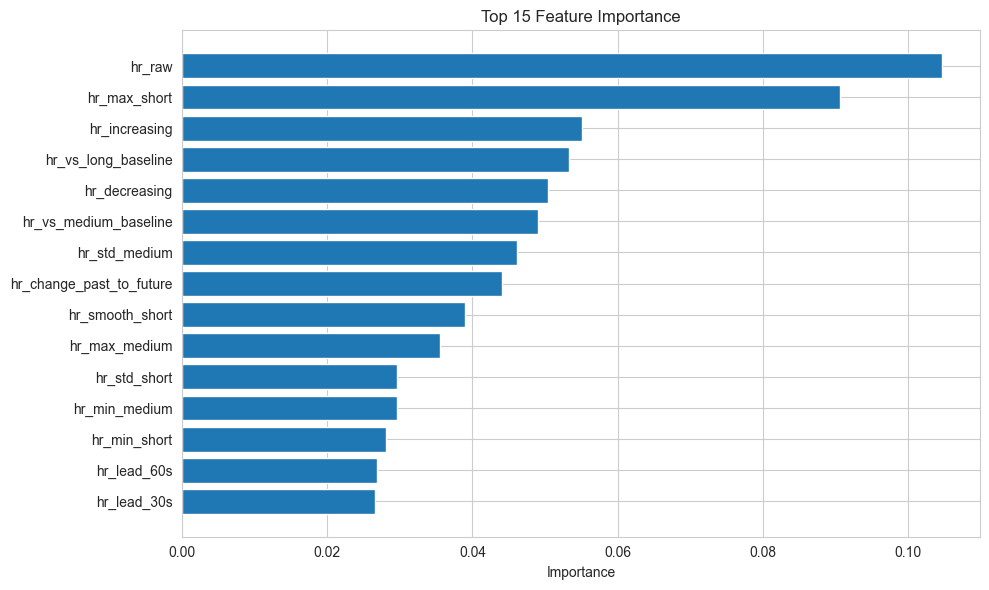

In [13]:
if hasattr(model, 'feature_importances_'):
    feature_names = test_sessions_data[0]['feature_names']
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔝 Top 10 Most Important Features:")
    for idx, row in importance_df.head(10).iterrows():
        print(f"   {row['feature']:30s} {row['importance']:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. Visualize All Test Sessions

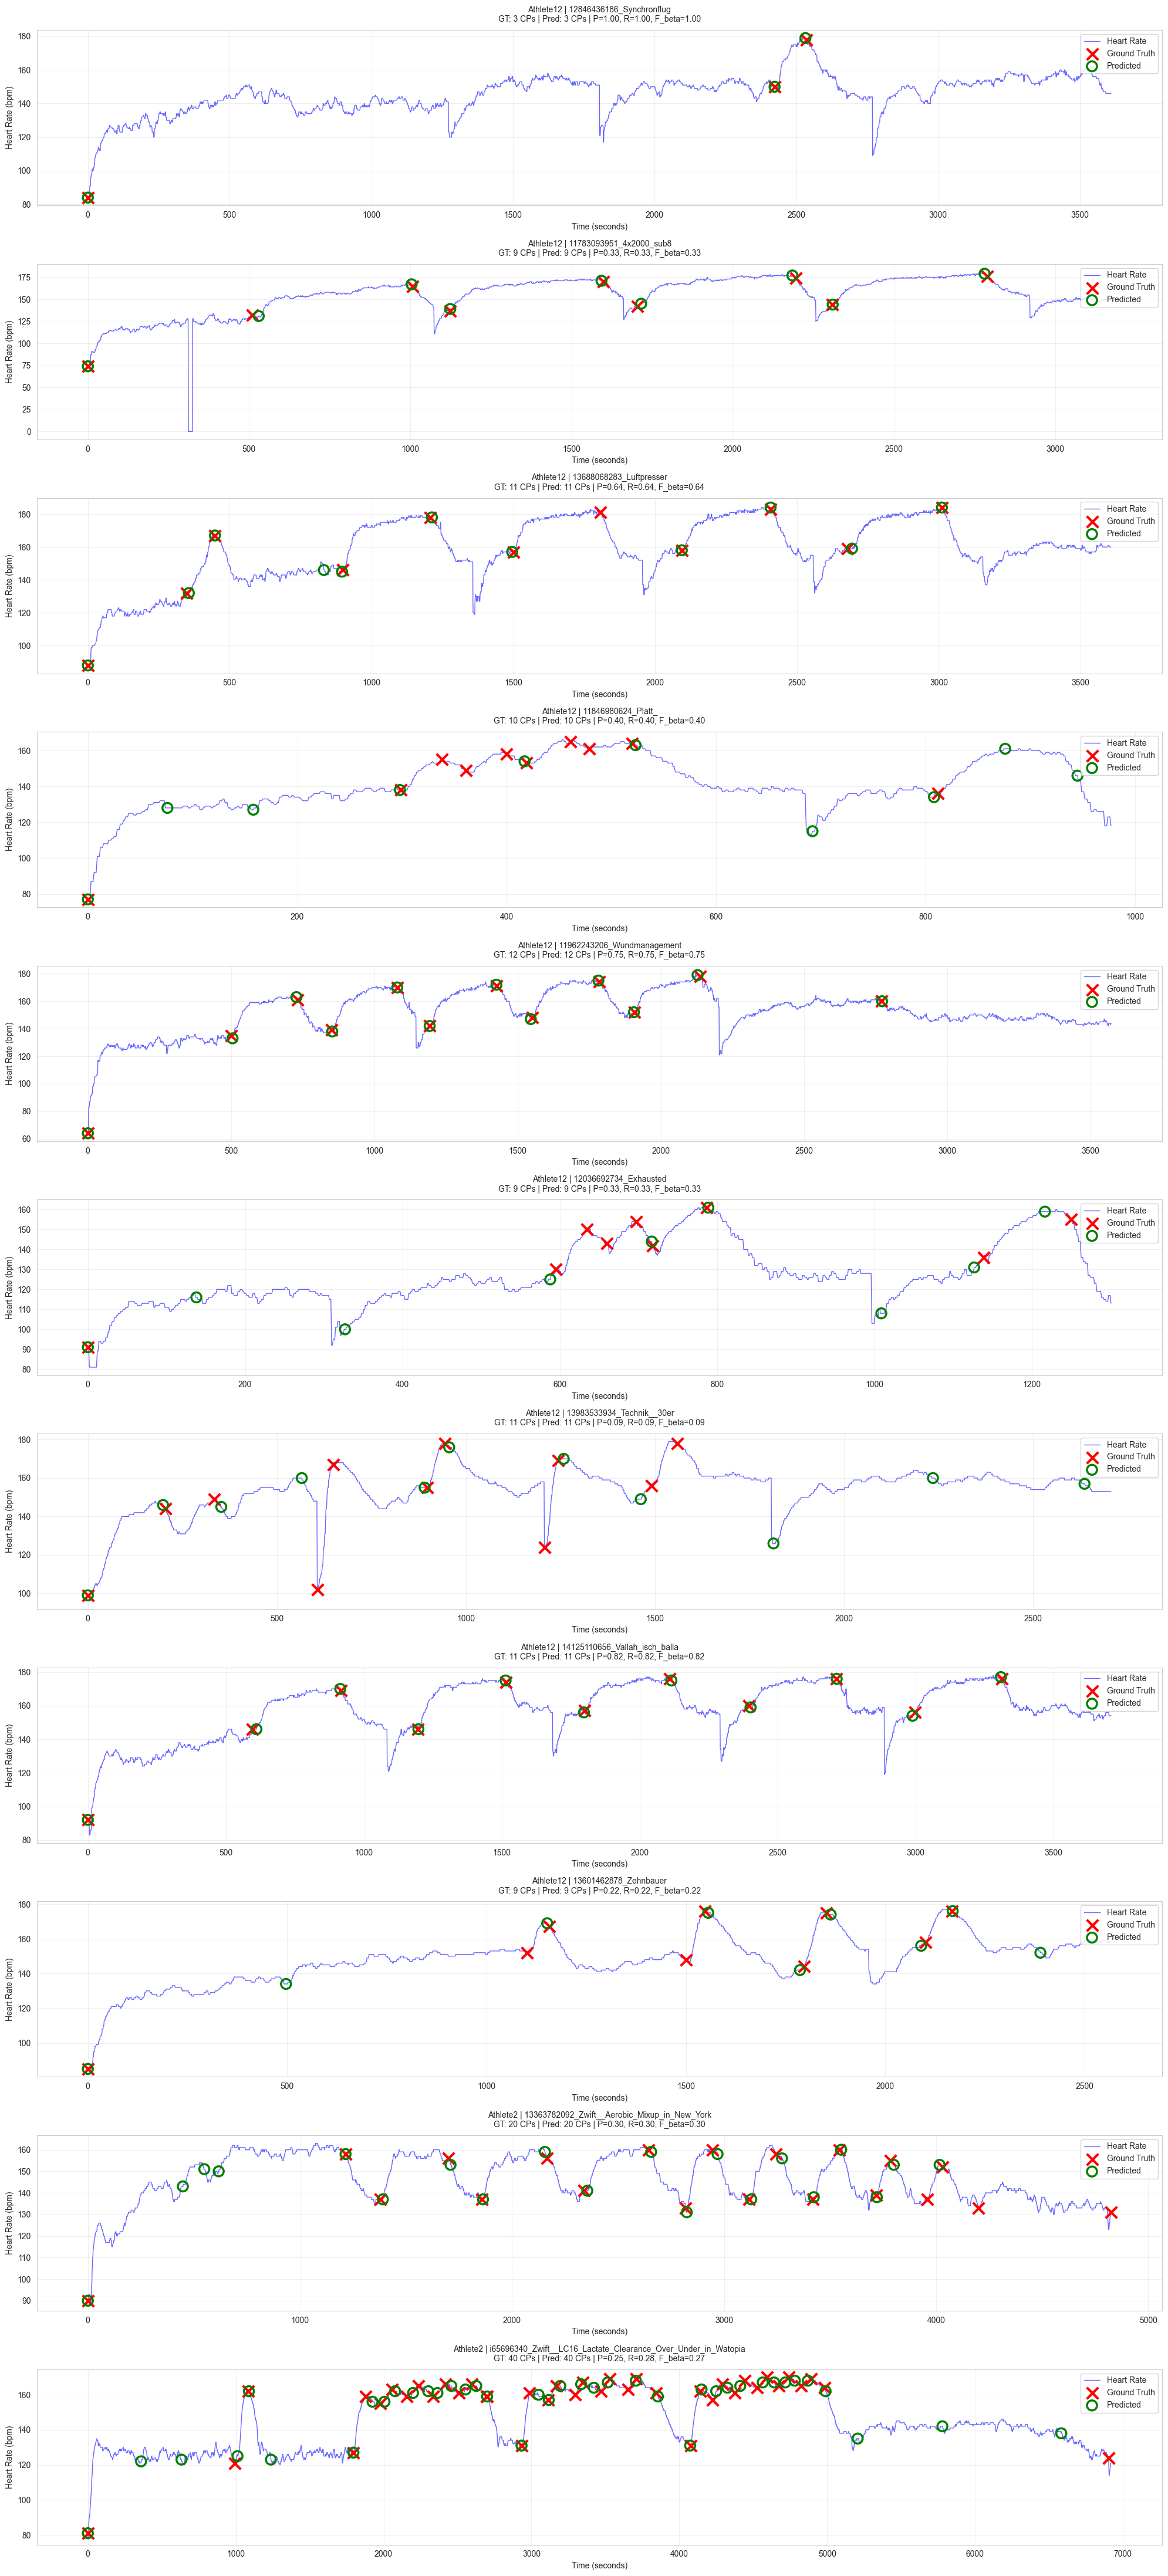

In [14]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Plot heart rate
    axes[idx].plot(hr_values, label='Heart Rate', color='blue', alpha=0.6, linewidth=1)
    
    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]
    
    # Mark ground truth change points with RED X
    for cp in gt_cps:
        if cp < len(hr_values):
            axes[idx].scatter(cp, hr_values[cp], marker='x', s=200, color='red',
                            linewidths=3, zorder=5, label='Ground Truth' if cp == gt_cps[0] else '')
    
    # Mark predicted change points with GREEN O
    for cp in pred_cps:
        if cp < len(hr_values):
            axes[idx].scatter(cp, hr_values[cp], marker='o', s=150,
                            facecolors='none', edgecolors='green', linewidths=2.5,
                            zorder=5, label='Predicted' if cp == pred_cps[0] else '')
    
    # Set title with session info and metrics
    axes[idx].set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )
    
    axes[idx].set_ylabel('Heart Rate (bpm)')
    axes[idx].set_xlabel('Time (seconds)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics

In [15]:
print("\n" + "="*80)
print("SUMMARY BY SESSION")
print("="*80)

total_gt = 0
total_pred = 0

for result in test_results:
    total_gt += result['n_true']
    total_pred += result['n_pred']
    
    print(f"\n{result['athlete'][:10]:10s} | {result['session'][:40]:40s}")
    print(f"  GT CPs: {result['n_true']:2d} | Pred CPs: {result['n_pred']:2d}")
    print(f"  P={result['precision']:.3f} | R={result['recall']:.3f} | F_beta={result['f_beta']:.3f} | Error={result['mean_error_sec']:.1f}s")

# Overall statistics
avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)
print(f"Total Ground Truth CPs: {total_gt}")
print(f"Total Predicted CPs: {total_pred}")
print(f"\nAverage Precision: {avg_precision:.3f}")
print(f"Average Recall: {avg_recall:.3f}")
print(f"Average F-BETA: {avg_f_beta:.3f}")
print(f"Average Error: {avg_error:.1f} seconds")
print("\nNote: Metrics use -3 and +7 second tolerance")


SUMMARY BY SESSION

Athlete12  | 12846436186_Synchronflug                
  GT CPs:  3 | Pred CPs:  3
  P=1.000 | R=1.000 | F_beta=1.000 | Error=1.3s

Athlete12  | 11783093951_4x2000_sub8                 
  GT CPs:  9 | Pred CPs:  9
  P=0.333 | R=0.333 | F_beta=0.333 | Error=6.8s

Athlete12  | 13688068283_Luftpresser                 
  GT CPs: 11 | Pred CPs: 11
  P=0.636 | R=0.636 | F_beta=0.636 | Error=9.5s

Athlete12  | 11846980624_Platt_                      
  GT CPs: 10 | Pred CPs: 10
  P=0.400 | R=0.400 | F_beta=0.400 | Error=54.4s

Athlete12  | 11962243206_Wundmanagement              
  GT CPs: 12 | Pred CPs: 12
  P=0.750 | R=0.750 | F_beta=0.750 | Error=2.8s

Athlete12  | 12036692734_Exhausted                   
  GT CPs:  9 | Pred CPs:  9
  P=0.333 | R=0.333 | F_beta=0.333 | Error=65.7s

Athlete12  | 13983533934_Technik__30er               
  GT CPs: 11 | Pred CPs: 11
  P=0.091 | R=0.091 | F_beta=0.091 | Error=194.3s

Athlete12  | 14125110656_Vallah_isch_balla           
  GT

## ✅ Done!

Your model is now trained and evaluated. Check the visualizations and metrics above.

**Key Outputs:**
- Overall F1, Precision, Recall, Error
- Per-session detailed metrics
- Feature importance
- Visualization plots

**To use on new data:**
- Use cell 15 (predict on new session)
- You have: `model`, `scaler`, `CONFIG` ready to use